In [3]:
fname = "C:/Users/dinab/Desktop/PhD Projects/Elsa Olesya/stata/stata13_se"

In [199]:
import pandas as pd
import numpy as np

In [86]:
df3 = pd.read_stata("h_elsa_g3.dta")

# Dictionary

## Demographic variables

In [ ]:
Age, education , place of birth (UK or not)
R1AGEY - age at interview (1...9)
RAGENDER - gender 
RARACEM - race (White or non-White)
RAEDUC_E - education
RAEDYRS_E - education years 
RAEDUCL - harmonized education  <upper secondary, upper secondary, tertiary 
r1mstat:w1 r marital status w/partners, filled 
r1mpart:w1 r implied partnership status
RABPLACE -  UK or outside 
RARELIG_E - religion

WEALTH
Total Family Wealth 
 H1ATOTB          h1atotb:w1 total all assets inc. 2nd hm      
H1ITOT           h1itot:w1 income: total couple level income          

Employment 
 R1WORK           r1work:w1 R working for pay   
 R1SLFEMP         r1slfemp:w1 r Whether Self-Employed         
 R1LBRF_E         r1lbrf_e:w1 R labor force status   


## Health

## Congnition and Behaviour

Pain 
 R1PAINFR         r1painfr:w1 r frequent problems with pain   
 R1PAINLV         r1painlv:w1 r usual level of pain    
 R1LEGPN          r1legpn:w1 r pain in legs              

Urinary Incontinence 
 R1URINAI         r1urinai:w1 r any urinary incontinence      

Persistent Health Problems 
 R1BREATH_E       r1breath_e:w1 r short of breath while walking   
 R1WHEEZE_E       r1wheeze_e:w1 r persistent wheezing
 

# Getting the data 

In [113]:
df3.shape #19,802 x 11,779

(19802, 11779)

In [295]:
# add date1. ... date9 to the dataframe from month and year - to df 
df3 = df3.assign(date1 = df3.r1iwindy + round(df3.r1iwindm/12,2), date2 = df3.r2iwindy + round(df3.r2iwindm/12,2),
                   date3 = df3.r3iwindy + round(df3.r3iwindm/12,2), date4 = df3.r4iwindy + round(df3.r4iwindm/12,2),
                   date5 = df3.r5iwindy + round(df3.r5iwindm/12,2), date6 = df3.r6iwindy + round(df3.r6iwindm/12,2),
                   date7 = df3.r7iwindy + round(df3.r7iwindm/12,2), date8 = df3.r8iwindy + round(df3.r8iwindm/12,2), 
                   date9 = df3.r9iwindy + round(df3.r9iwindm/12,2))


### Adding socio-demographic variables

In [1364]:
# start creating data frame with only what we need
mydf = df3[["idauniq"]]

In [1366]:
# --- add year of birth and death, yod, yob -- 
mydf = mydf.assign(yob = df3.rabyear, yod = df3.radyear)
# --- sex --
mydf['sex'] = df3['ragender'].map({'1.man': 0, '2.woman': 1}).fillna(np.nan)
#--- ethnic group  --
mydf['eth'] = df3['raracem'].map( {'1.white' : 0, '4.non-white':1})
#--- education --
mydf['edu'] = df3['raeducl'].map( {'1.less than upper secondary' : 1, '3.tertiary':3, 
                                   '2.upper secondary and vocational training':2,'.o:other' :2 }) #group other into 2 for "training" etc  mydf.edu.value_counts()
#--- wealth in quintiles --
#mydf["wealth9"] =  pd.qcut(df3['h9atotb'], q=5, labels=[1, 2, 3, 4, 5]) #in categorical format 
#mydf["wealth9"] = mydf["wealth9"].astype("float") # convert to numeric
#same as above in a loop
for i in range(1, 10):
    col_name = f'h{i}atotb'
    new_col_name = f'wealth{i}'
    mydf[new_col_name] = pd.qcut(df3[col_name], q=5, labels=[1, 2, 3, 4, 5])
    mydf[new_col_name] = mydf[new_col_name].astype('float')  # Convert to numeric
# add mean wealth for each person in case some years are missing (row-wise imputation so to say)
mydf["wealth"] = mydf.loc[:, [f'wealth{i}' for i in range(1, 10)]].mean(axis=1) 
# sum(np.isnan(mydf.wealth)) # 147 - only few are missing 

#--- add dates of the interviews date1. ... date9 to the dataframe from month and year - to mydf --
mydf = mydf.assign(date1 = df3.r1iwindy + round(df3.r1iwindm/12,2), date2 = df3.r2iwindy + round(df3.r2iwindm/12,2),
                   date3 = df3.r3iwindy + round(df3.r3iwindm/12,2), date4 = df3.r4iwindy + round(df3.r4iwindm/12,2),
                   date5 = df3.r5iwindy + round(df3.r5iwindm/12,2), date6 = df3.r6iwindy + round(df3.r6iwindm/12,2),
                   date7 = df3.r7iwindy + round(df3.r7iwindm/12,2), date8 = df3.r8iwindy + round(df3.r8iwindm/12,2), 
                   date9 = df3.r9iwindy + round(df3.r9iwindm/12,2))
# impute missing values for the dates with mean by all patients, round till 3d decimal place 
date_columns = [f'date{i}' for i in range(1, 10)]  # List of date column names date1... date9
mydf[date_columns] = mydf[date_columns].apply(lambda col: col.fillna(col.mean()))
mydf[date_columns] = mydf[date_columns].round(3)

# employment - 1 for employed, self-emloyed and looking after family, 0 - unemployed and retired 
mydf['empl'] = df3.apply(lambda row: 1 if ((row['r1lbrf_e'] == '1.employed') |
                                          (row['r1lbrf_e'] == '7.looking after home or family')|
                                          (row['r1lbrf_e'] == '2.self-employed')) else 0, axis=1)


### Adding previous history of diseases

In [1368]:
# Age at first diagnosis of XXX - Record previous history 
mydf["angina"] = df3["radiagangin"]
mydf["heartattack"] = df3["rafrhrtatt"]
mydf["chf"] = df3["radiagchf"]
mydf["diabetes"] = df3["radiagdiab"]
mydf["stroke"] = df3["radiagstrok"]
mydf["arthritis"] = df3["radiagarthr"]
mydf["cancer"] = df3["radiagcancr"]
mydf["parkinson"] = df3["radiagparkin"]
mydf["psych"] = df3["radiagpsych"]
mydf["last_period"] = df3.r4lstmnspd

# Age at death
mydf["death"] = mydf.yod - mydf.yob #age at death

In [1369]:
# Depression  - from medication 
#(df3.r2rxdepres =="1.Yes")

# Find first "1.Yes" in depression columns and map it to corresponding age
df3["depression_age2"] = 1000.1; df3["depression_age4"] = 1000.1; df3["depression_age8"] = 1000.1; mydf["depression"] = 1000.1
c2 = (df3.r2rxdepres == "1.Yes"); c4 = (df3.r4rxdepres == "1.Yes" ); c8 = (df3.r8rxdepres == "1.Yes")
df3.loc[c2, "depression_age2"] =  df3.loc[c2, "date2"] - df3.loc[c2, "rabyear"]
df3.loc[c4, "depression_age4"] =  df3.loc[c4, "date2"] - df3.loc[c4, "rabyear"]
df3.loc[c8, "depression_age8"] =  df3.loc[c8, "date2"] - df3.loc[c8, "rabyear"]
mydf.depression = df3[['depression_age2', 'depression_age4', 'depression_age8']].min(axis=1)
mydf['depression'] = mydf['depression'].replace(1000.1, np.nan) # replace back all 1000 with nans
#df3["depression_age"].hist()

In [1370]:
# add ages for all the conditions availabe in HEALTH (for "ever" questions)
conditions =["lung", "hibp","diab", "cancr","heart", "strok",
             "psych", "arthr", "asthma", "catract", "parkin", #0 1 2 3 4 5 
             "hip",  "angin","hrtatt", "hrtrhm", "hrtmr", "osteo", "hyster"]

def getever (j, w) : return( f"r{w}{conditions[j]}e")     # creates names like r3lunge, where have you have had lung disease? answered 

# function to get the first age for conditions from the "conditions" list
def getage (condition_n):
    waves = range(1,10)
    if conditions[condition_n] =="hyster":  waves = [4,6,7] 
    pl = pd.DataFrame(np.full((df3.shape[0], 10), 1000.1))
    for i in waves:
        ci = ( df3[getever (condition_n, i)] == "1.yes" )| ( df3[getever (condition_n, i)] == "1.Yes" ) # vector TRUE or False if the condition was in <= wave i
        #print(sum(ci))
        pl.loc[ci, i-1] =  df3.loc[ci, f"date{i}"] - df3.loc[ci, "rabyear"]
    pl.loc[:, 10] = pl.loc[:, 0:9].min(axis=1)
    output = pl.loc[:, 10].replace(1000.1, np.nan)
    return output

# now populate results into mydf into columns with the names from conditions 
for j in range(len(conditions)): mydf[conditions[j]] = getage(j)



In [1371]:
# CHIDHOOD HEALTH (before the age 16)
chconditions =["infect","asthma", "resp","allerg", "hdache", "epilepsy",  "psych",
                   "bones", "appdcts", "diab", "heart",  "leuk",  "cancer"]

child_conditions = [f"rach{c}" for c in chconditions]
child_conditions_myname = [f"child_{c}" for c in chconditions]
# check how many had these problems:
#[sum(df3[child_conditions[i]]=="1.yes") for i in range(len(child_conditions))] 
#[7145, 270, 701, 493, 407, 57, 147, 1281, 446, 3, 102, 0, 5]

# adding columns wiht  child_conditions_myname with the age = 16 or random between 5 and 16
for i in range(len(child_conditions)):
    mydf[child_conditions_myname[i]]  = np.nan
    mydf.loc[ df3[child_conditions[i]]=="1.yes", child_conditions_myname[i]] = np.random.randint(1, 17, size=sum(df3[child_conditions[i]]=="1.yes"))

In [1372]:
mydf[conditions].describe()

,lung,hibp,diab,cancr,heart,strok,psych,arthr,asthma,catract,parkin,hip,angin,hrtatt,hrtrhm,hrtmr,osteo,hyster
count,1642.000000,8785.000000,2539.000000,2484.000000,5046.000000,1360.000000,2158.000000,7736.000000,2761.000000,5908.000000,231.000000,510.000000,1815.000000,1373.000000,2452.000000,1211.000000,1766.000000,1580.000000
mean,68.593179,65.986734,67.127574,69.193366,69.643082,73.837397,61.209694,66.759704,62.602086,73.491192,73.331082,78.516196,70.668804,70.749862,70.005644,68.867754,70.893998,66.609032
std,10.144466,10.481153,10.165760,10.457503,11.009666,10.530442,10.311843,10.481007,10.615735,8.948933,9.569511,9.430042,9.903254,10.470593,11.006259,12.192495,10.813242,10.094708
min,34.420000,35.080000,37.750000,40.920000,33.750000,41.000000,31.080000,34.000000,21.580000,40.580000,41.080000,60.330000,44.330000,41.750000,34.000000,33.750000,45.500000,40.920000
25%,60.500000,57.170000,58.750000,61.457500,60.830000,66.330000,53.750000,58.080000,54.080000,67.580000,67.455000,70.852500,62.875000,63.000000,61.230000,58.330000,62.080000,58.670000
50%,68.250000,65.420000,66.750000,69.250000,69.920000,74.420000,58.500000,65.830000,60.750000,73.670000,74.000000,79.540000,70.920000,70.830000,70.500000,69.330000,70.830000,65.500000
75%,75.830000,73.670000,74.420000,76.750000,77.920000,82.080000,66.897500,74.352500,70.000000,79.830000,79.960000,86.000000,78.125000,78.500000,78.170000,78.670000,79.230000,73.670000
max,95.830000,99.000000,100.920000,102.580000,100.920000,101.750000,103.750000,98.920000,97.170000,101.580000,92.750000,102.080000,94.920000,98.170000,97.670000,97.170000,99.830000,97.000000


In [1373]:
df3["rachshlt"].value_counts() #overall childgood health  #later we can fill "healthy for those with excellent and very good

rachshlt
.l:no life history ivw          11952
1.excellent                      2710
2.very good                      2603
3.good                           1593
4.fair                            645
5.poor                            259
6.health varied a great deal       33
.m:Missing                          4
.d:DK                               3
Name: count, dtype: int64

In [1374]:
mydf[child_conditions_myname].describe()

,child_infect,child_asthma,child_resp,child_allerg,child_hdache,child_epilepsy,child_psych,child_bones,child_appdcts,child_diab,child_heart,child_leuk,child_cancer
count,7145.000000,270.000000,701.000000,493.000000,407.000000,57.000000,147.000000,1281.000000,446.000000,3.000000,102.000000,0.0,5.000000
mean,8.549475,8.381481,8.550642,8.628803,8.265356,8.526316,8.462585,8.448087,8.367713,8.666667,8.049020,NaN,10.000000
std,4.630537,4.622439,4.583425,4.529279,4.526697,4.301600,4.603858,4.610687,4.577840,5.507571,4.543252,NaN,6.123724
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,NaN,3.000000
25%,5.000000,5.000000,5.000000,5.000000,4.000000,6.000000,4.000000,4.000000,4.000000,5.500000,4.000000,NaN,4.000000
50%,9.000000,8.000000,9.000000,8.000000,8.000000,8.000000,9.000000,8.000000,8.000000,6.000000,8.000000,NaN,12.000000
75%,13.000000,12.000000,12.000000,13.000000,12.000000,12.000000,12.000000,12.000000,12.000000,10.500000,12.000000,NaN,15.000000
max,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,16.000000,NaN,16.000000


In [1354]:
# repeated problems if recorded: 
# r1angin:w1 r had angina last 2 years 
# r1hrtatt:w1 r had heart attack last 2 years    
# r1psych:w1 r had psychiatric problem last 2 years   

#--  Some insights if new are many (=> there are, will add repeated heart attack 

# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}angin" for i in range(1,10)]] ) # current angina 
# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}angine" for i in range(1,10)]]) # ever angina
# # [684, 253, 379, 402, 383, 321, 145, 140, 117]
# # [1079, 899, 814, 838, 810, 753, 671, 600, 525]

# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}hrtatt" for i in range(1,10)]]) # current heart attacks 
# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}hrtatte" for i in range(1,10)]]) # new heart attacks 
# # [154, 17, 153, 167, 152, 156, 151, 125, 107]
# # [679, 539, 520, 519, 521, 526, 481, 448, 436]

# print ([sum(df3[c] == "1.Yes") for c in [f"r{i}psych" for i in range(1,10)]]) # current psychological
# print ([sum(df3[c] == "1.yes") for c in [f"r{i}psyche" for i in range(1,10)]]) # ever psychological
# # [576, 363, 551, 642, 611, 717, 624, 92, 234]
# # [812, 784, 851, 987, 992, 1108, 1082, 1041, 1086]

# adding repeated heart attacks 


In [1375]:
### SAVE TO CSV 
# mydf.to_csv("C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/elsa_journeys_short.csv") 

In [1306]:
mydf.shape

(19802, 67)

In [1356]:
mydf.columns

Index(['idauniq', 'yob', 'yod', 'sex', 'eth', 'edu', 'wealth1', 'wealth2',
       'wealth3', 'wealth4', 'wealth5', 'wealth6', 'wealth7', 'wealth8',
       'wealth9', 'wealth', 'date1', 'date2', 'date3', 'date4', 'date5',
       'date6', 'date7', 'date8', 'date9', 'empl', 'angina', 'heartattack',
       'chf', 'diabetes', 'stroke', 'arthritis', 'cancer', 'parkinson',
       'psych', 'last_period', 'death', 'lung', 'hibp', 'diab', 'cancr',
       'heart', 'strok', 'arthr', 'asthma', 'catract', 'parkin', 'hip',
       'angin', 'hrtatt', 'hrtrhm', 'hrtmr', 'osteo', 'hyster', 'child_infect',
       'child_asthma', 'child_resp', 'child_allerg', 'child_hdache',
       'child_epilepsy', 'child_psych', 'child_bones', 'child_appdcts',
       'child_diab', 'child_heart', 'child_leuk', 'child_cancer',
       'depression'],
      dtype='object')

In [1473]:
mydf.iloc[0:3, ]

,idauniq,yob,yod,sex,eth,edu,wealth1,wealth2,wealth3,wealth4,...,child_hdache,child_epilepsy,child_psych,child_bones,child_appdcts,child_diab,child_heart,child_leuk,child_cancer,born
0,100001,1951.0,NaN,0,0.0,1.0,NaN,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,100005,1947.0,NaN,0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,100006,1951.0,NaN,0,0.0,1.0,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [1475]:
### CREATING LONG FORMAT ### 
mydf["born"] = 0
events = child_conditions_myname + conditions + ["depression", "death", "born"] 
events = [event for event in events if event != "heart"]
len(events)
print(events)

['child_infect', 'child_asthma', 'child_resp', 'child_allerg', 'child_hdache', 'child_epilepsy', 'child_psych', 'child_bones', 'child_appdcts', 'child_diab', 'child_heart', 'child_leuk', 'child_cancer', 'lung', 'hibp', 'diab', 'cancr', 'strok', 'psych', 'arthr', 'asthma', 'catract', 'parkin', 'hip', 'angin', 'hrtatt', 'hrtrhm', 'hrtmr', 'osteo', 'hyster', 'depression', 'death', 'born']


<Axes: >

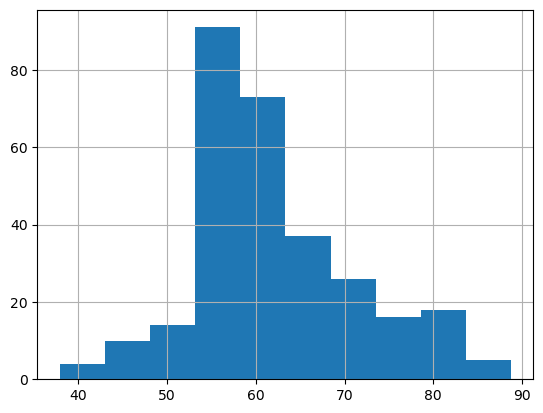

In [1477]:
mydf.depression.hist()

In [1497]:
mydf.loc[np.isnan(mydf.death)==False, :]

,idauniq,yob,yod,sex,eth,edu,wealth1,wealth2,wealth3,wealth4,...,child_hdache,child_epilepsy,child_psych,child_bones,child_appdcts,child_diab,child_heart,child_leuk,child_cancer,born
20,100038,1937.0,2006.0,1,0.0,NaN,2.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
49,100067,1930.0,2005.0,0,0.0,2.0,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
137,102626,1926.0,2005.0,0,0.0,1.0,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
195,103735,1931.0,2009.0,0,0.0,1.0,4.0,3.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
199,103739,1916.0,2008.0,0,0.0,2.0,3.0,3.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16167,162047,1940.0,2011.0,1,0.0,2.0,NaN,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
16298,162178,1933.0,2009.0,0,0.0,1.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
16445,162325,1941.0,2012.0,1,0.0,2.0,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
16473,162353,1937.0,2011.0,1,0.0,1.0,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [1479]:
long_df = mydf[events + ["idauniq"]].melt(id_vars=['idauniq'], var_name='event', value_name='age').dropna()
long_df = long_df.sort_values(by=['idauniq', 'age']) 
long_df.index = range(1, len(long_df) + 1) #row names to 1 2. ... 
# add context variables 
long_df = long_df.merge(mydf[['idauniq', 'sex', 'wealth', 'edu', 'eth']], on='idauniq', how='left')


In [1483]:
long_df.loc[0:20, :]

,idauniq,event,age,sex,wealth,edu,eth
0,100001,born,0.00,0,1.000000,1.0,0.0
1,100001,hibp,60.00,0,1.000000,1.0,0.0
2,100001,diab,60.00,0,1.000000,1.0,0.0
3,100005,born,0.00,0,2.500000,1.0,0.0
4,100006,born,0.00,0,2.333333,1.0,0.0
5,100006,lung,58.08,0,2.333333,1.0,0.0
6,100006,hibp,58.08,0,2.333333,1.0,0.0
7,100006,psych,58.08,0,2.333333,1.0,0.0
8,100006,arthr,58.08,0,2.333333,1.0,0.0
9,100006,osteo,60.00,0,2.333333,1.0,0.0


In [1499]:
long_df.loc[long_df.idauniq == 100067, :]

,idauniq,event,age,sex,wealth,edu,eth
172,100067,born,0.00,0,2.0,2.0,0.0
173,100067,hibp,72.33,0,2.0,2.0,0.0
174,100067,strok,72.33,0,2.0,2.0,0.0
175,100067,arthr,72.33,0,2.0,2.0,0.0
176,100067,angin,72.33,0,2.0,2.0,0.0
177,100067,osteo,72.33,0,2.0,2.0,0.0
178,100067,death,75.00,0,2.0,2.0,0.0


In [1503]:
### SAVE TO CSV 
# long_df.to_csv("C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/long_df.csv") 